# Import Libraries

In [16]:
import numpy as np
import SimpleITK as sitk
import matplotlib.pyplot as plt
from tabulate import tabulate
from PIL import Image, ImageDraw
import math
import pandas as pd

# Utils

In [15]:
#==============================
# Colors for different nodule labels
#==============================
COLORS = [
    (255,   0,   0, 120),   # Red
    (  0, 255,   0, 120),   # Green
    (  0,   0, 255, 120),   # Blue
    (255, 255,   0, 120),   # Yellow
    (255,   0, 255, 120),   # Magenta
    (  0, 255, 255, 120),   # Cyan
    (255, 128,   0, 120),   # Orange
    (128,   0, 255, 120),   # Purple
]

#==============================
# Overlay Mask on CT
#==============================
def overlay_mask_on_ct(ct_slice, mask_slice, colors, title=""):
    """
    Overlay a segmentation mask on a CT slice.

    Parameters
    ----------
    ct_slice : ndarray
        2D CT slice.
    mask_slice : ndarray
        2D segmentation mask.
    colors : list
        RGBA colors for each label.
    title : str
        Image title.

    Returns
    -------
    PIL.Image
        Overlay image.
    """

    # Normalize CT
    ct_norm = (ct_slice - ct_slice.min()) / (ct_slice.max() - ct_slice.min())
    ct_uint8 = (ct_norm * 255).astype(np.uint8)

    ct_img = Image.fromarray(ct_uint8).convert("RGB")

    # Create transparent overlay
    overlay = Image.new("RGBA", ct_img.size, (0, 0, 0, 0))
    overlay_pixels = overlay.load()

    labels = np.unique(mask_slice)
    labels = labels[labels > 0]

    for label in labels:

        color = colors[(label - 1) % len(colors)]

        ys, xs = np.where(mask_slice == label)

        for y, x in zip(ys, xs):
            overlay_pixels[x, y] = color

    result = Image.alpha_composite(
        ct_img.convert("RGBA"),
        overlay
    ).convert("RGB")

    # Add title
    title_height = 25

    canvas = Image.new(
        "RGB",
        (result.width, result.height + title_height),
        "white"
    )

    canvas.paste(result, (0, title_height))

    draw = ImageDraw.Draw(canvas)
    draw.text((5, 5), title, fill="black")

    return canvas


#==============================
# Create Image Grid
#==============================
def create_image_grid(images, cols=5, padding=15):
    """
    Arrange images into a grid.
    """

    rows = math.ceil(len(images) / cols)

    img_w = images[0].width
    img_h = images[0].height

    grid = Image.new(
        "RGB",
        (
            cols * img_w + (cols - 1) * padding,
            rows * img_h + (rows - 1) * padding,
        ),
        "white",
    )

    for i, img in enumerate(images):

        row = i // cols
        col = i % cols

        x = col * (img_w + padding)
        y = row * (img_h + padding)

        grid.paste(img, (x, y))

    return grid


#==============================
# Extract Mask ScanLevel-Atributes 
#==============================
def extract_mask_scan_level_attributes(mask_image):
    """
    Extract scan-level attributes from a LNDb mask.

    Parameters
    ----------
    mask_image : SimpleITK.Image
        LNDb mask image.

    Returns
    -------
    dict
        Dictionary containing scan-level attributes.
    """

    # Convert to NumPy array
    mask_volume = sitk.GetArrayFromImage(mask_image)

    # Image information
    size = mask_image.GetSize()
    spacing = mask_image.GetSpacing()
    shape = mask_volume.shape

    # Find slices containing nodules
    nodule_slices = np.where(np.any(mask_volume > 0, axis=(1, 2)))[0]

    # Number of nodules (exclude background label 0)
    num_nodules = len(np.unique(mask_volume)) - 1

    # Number of voxels belonging to nodules
    mask_voxel_count = int(np.count_nonzero(mask_volume))

    # Physical volume of one voxel (mm³)
    voxel_volume_mm3 = spacing[0] * spacing[1] * spacing[2]

    # Total nodule volume (mm³)
    total_nodule_volume_mm3 = mask_voxel_count * voxel_volume_mm3

    attributes = {
        "size": size,
        "spacing": spacing,
        "shape": shape,

        "num_nodules": num_nodules,

        "slice_start": int(nodule_slices[0]),
        "slice_end": int(nodule_slices[-1]),
        "num_slices_with_nodule": len(nodule_slices),

        "mask_voxel_count": mask_voxel_count,
        "voxel_volume_mm3": voxel_volume_mm3,
        "total_nodule_volume_mm3": total_nodule_volume_mm3,

        "nodule_slices": nodule_slices.tolist()
    }

    return attributes

# Configuration

In [9]:
CT_PATH = "../dataset/lndb/data/LNDb-0001.mhd"
MASK_PATHS = [
    "../dataset/lndb/masks/LNDb-0001_rad1.mhd",
    "../dataset/lndb/masks/LNDb-0001_rad2.mhd",
    "../dataset/lndb/masks/LNDb-0001_rad3.mhd",
]

# Load .mhd Data

In [ ]:
# load scan data
# .mhd is metadata file
ct = sitk.ReadImage(CT_PATH)
mask = sitk.ReadImage(MASK_PATHS[0])

# get numpy array from SimpleITK image object
ct_volume = sitk.GetArrayFromImage(ct)
mask_volume = sitk.GetArrayFromImage(mask)

print(f"CT Size: {ct.GetSize()}")
print(f"Mask Size: {mask.GetSize()}")
print(f"Mask Unique Value: {np.unique(mask_volume)}")

CT Size: (512, 512, 328)
Mask Size: (512, 512, 328)
Mask Unique Value: [0 1 2]


# Metadata Inside .mhd File

In [8]:
data_scan = [
    ['CT size', ct.GetSize(), type(ct.GetSize())],
    ['CT spacing', ct.GetSpacing(), type(ct.GetSpacing())],
    ['Mask size', mask.GetSize(), type(mask.GetSize())],
    ['Mask spacing', mask.GetSpacing(), type(mask.GetSpacing())],
    ['CT shape', ct_volume.shape, type(ct_volume.shape)],
    ['Mask shape', mask_volume.shape, type(mask_volume.shape)],
    ['CT min HU', ct_volume.min(), type(ct_volume.min())],
    ['CT max HU', ct_volume.max(), type(ct_volume.max())],
    ['Mask unique values', np.unique(mask_volume).tolist(), type(np.unique(mask_volume))]
]

print(tabulate(
    data_scan,
    headers=['Attribute','Value','Type'],
    tablefmt='grid'
))

+--------------------+---------------------------------+-------------------------+
| Attribute          | Value                           | Type                    |
+====================+=================================+=========================+
| CT size            | (512, 512, 328)                 | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| CT spacing         | (0.607421875, 0.607421875, 1.0) | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| Mask size          | (512, 512, 328)                 | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| Mask spacing       | (0.607421875, 0.607421875, 1.0) | <class 'tuple'>         |
+--------------------+---------------------------------+-------------------------+
| CT shape           | (328, 512, 512)                 | <class 'tuple'>         |
+---

```text
- Size and Spacing Format -> (x, y, z) or (width, height, slice)
- Shape Format            -> (z, x, y) or (slice, width, height)
```

# Visualizing CT Images with Nodule Mask Overlay

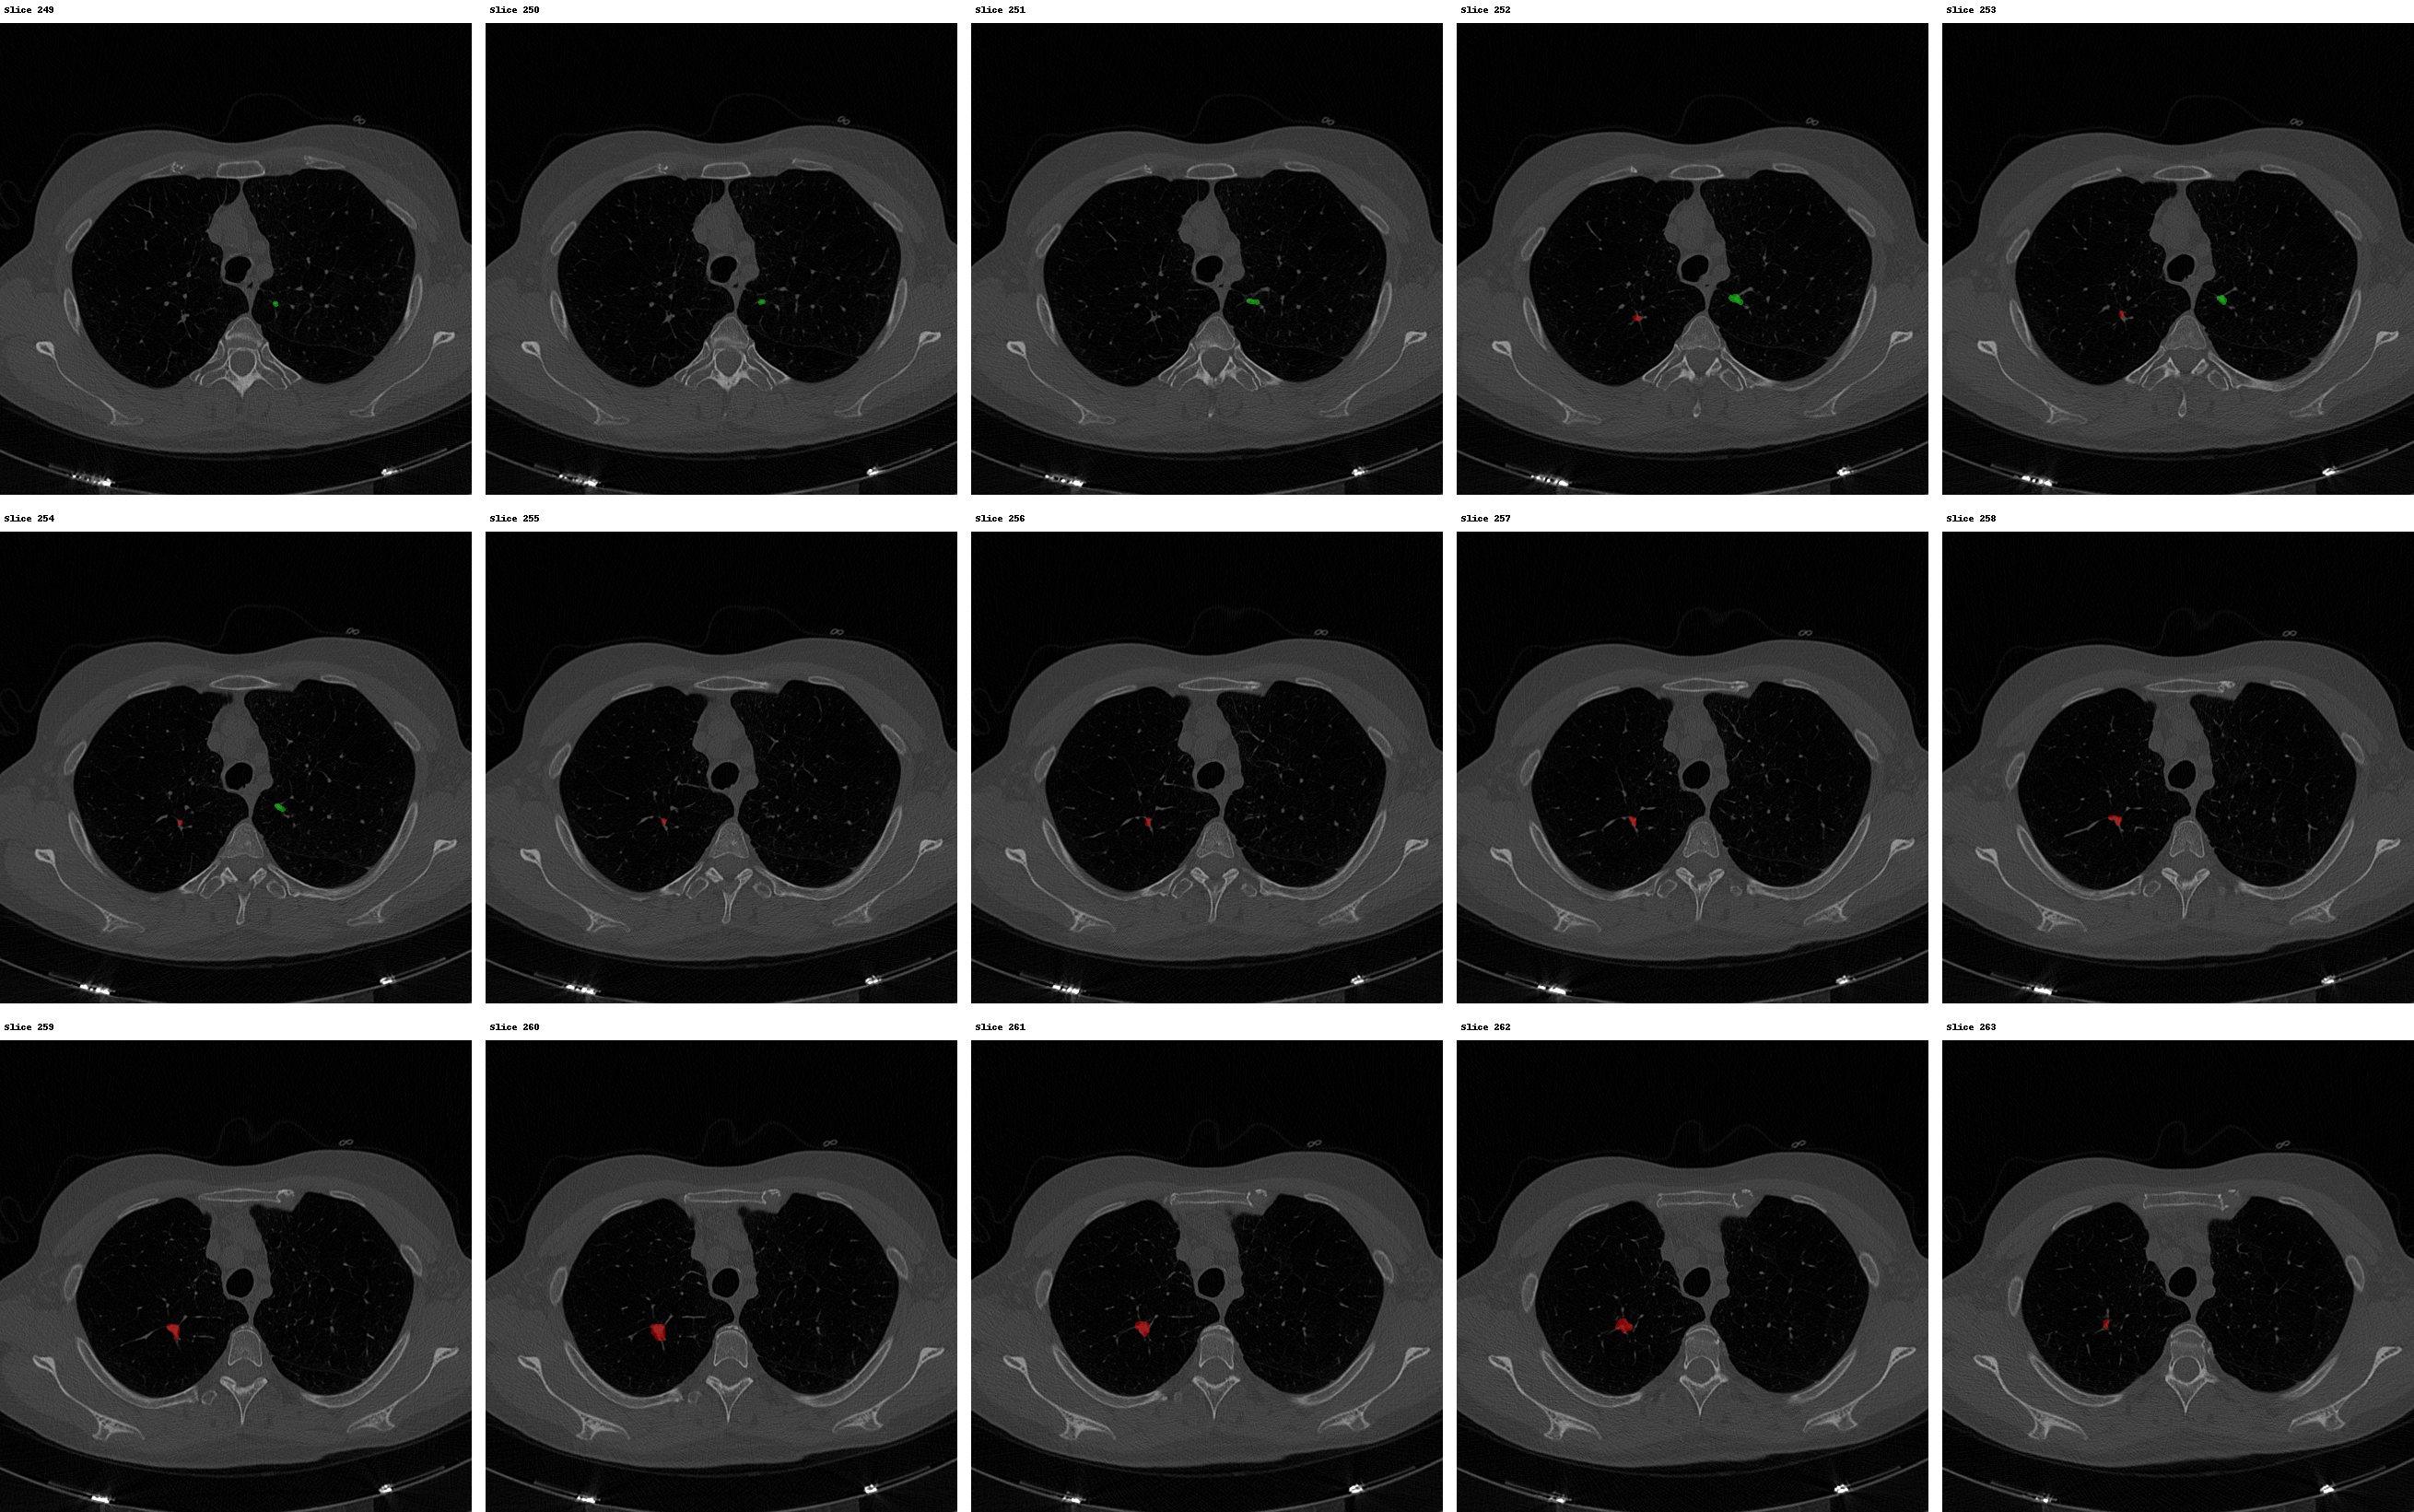

In [7]:
slices = np.where(np.any(mask_volume > 0, axis=(1, 2)))[0]

images = []

for slice_idx in slices:

    images.append(
        overlay_mask_on_ct(
            ct_volume[slice_idx],
            mask_volume[slice_idx],
            COLORS,
            title=f"Slice {slice_idx}"
        )
    )

grid = create_image_grid(images, cols=5)

display(grid)

# Mask From Multiple Radiologists

In [17]:
mask_images = [sitk.ReadImage(path) for path in MASK_PATHS]

scan_attributes = []

for mask_image in mask_images:
    scan_attributes.append(extract_mask_scan_level_attributes(mask_image))

df = pd.DataFrame(scan_attributes)
display(df)

,size,spacing,shape,num_nodules,slice_start,slice_end,num_slices_with_nodule,mask_voxel_count,voxel_volume_mm3,total_nodule_volume_mm3,nodule_slices
0,"(512, 512, 328)","(0.607421875, 0.607421875, 1.0)","(328, 512, 512)",2,249,263,15,1608,0.368961,593.289825,"[249, 250, 251, 252, 253, 254, 255, 256, 257, ..."
1,"(512, 512, 328)","(0.607421875, 0.607421875, 1.0)","(328, 512, 512)",1,260,260,1,154,0.368961,56.820045,[260]
2,"(512, 512, 328)","(0.607421875, 0.607421875, 1.0)","(328, 512, 512)",1,257,262,6,458,0.368961,168.984291,"[257, 258, 259, 260, 261, 262]"
